---
# **Q.  Build the bagging vs boosting intuition with a diagram**
---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import (AdaBoostClassifier, GradientBoostingClassifier,
                               RandomForestClassifier)
from sklearn.tree import DecisionTreeClassifier

data = load_breast_cancer()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# ── Conceptual comparison ──────────────────────────────────────────────────
print("BAGGING (Random Forest):")
print("  → Train N trees IN PARALLEL on bootstrap samples")
print("  → Each tree is fully independent")
print("  → Final prediction = majority vote")
print("  → Reduces VARIANCE — each tree has high variance, average cancels out")
print()
print("BOOSTING (AdaBoost / Gradient Boosting):")
print("  → Train N trees SEQUENTIALLY")
print("  → Each tree focuses on what the PREVIOUS ones got wrong")
print("  → Final prediction = weighted sum of all trees")
print("  → Reduces BIAS — ensemble gradually corrects systematic mistakes")

BAGGING (Random Forest):
  → Train N trees IN PARALLEL on bootstrap samples
  → Each tree is fully independent
  → Final prediction = majority vote
  → Reduces VARIANCE — each tree has high variance, average cancels out

BOOSTING (AdaBoost / Gradient Boosting):
  → Train N trees SEQUENTIALLY
  → Each tree focuses on what the PREVIOUS ones got wrong
  → Final prediction = weighted sum of all trees
  → Reduces BIAS — ensemble gradually corrects systematic mistakes


---
# **Q. AdaBoost sample weights: watch them shift after each round**
---


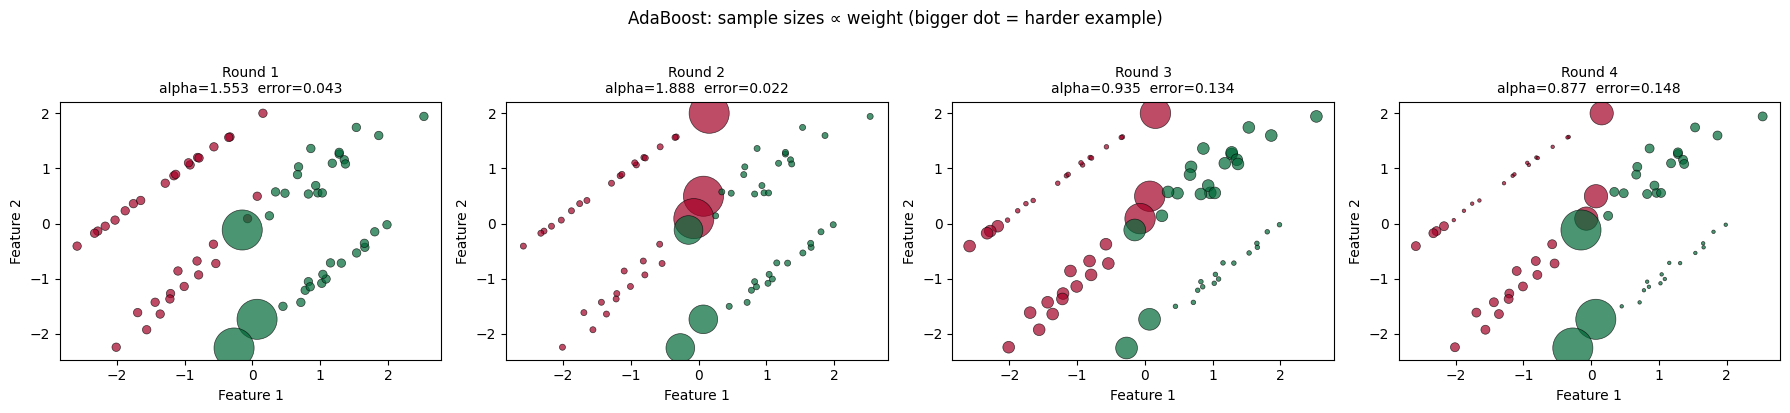

Interpretation: after each round, previously misclassified points
grow larger (higher weight) so the next stump focuses on them.


In [2]:
from sklearn.tree import DecisionTreeClassifier
import numpy as np

# Use a 2D toy dataset so we can visualise weight changes
from sklearn.datasets import make_classification
X2, y2 = make_classification(n_samples=100, n_features=2,
                              n_redundant=0, random_state=42)
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.3, random_state=42
)

n_train = len(y2_train)
weights = np.ones(n_train) / n_train   # uniform start

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
rounds = [1, 2, 3, 4]

for ax, round_n in zip(axes, rounds):
    # Train one "stump" (depth-1 tree) with current sample weights
    stump = DecisionTreeClassifier(max_depth=1, random_state=round_n)
    stump.fit(X2_train, y2_train, sample_weight=weights)

    preds = stump.predict(X2_train)
    correct = (preds == y2_train)

    # AdaBoost weight formula
    err = np.sum(weights[~correct]) / np.sum(weights)
    err = np.clip(err, 1e-10, 1 - 1e-10)
    alpha = 0.5 * np.log((1 - err) / err)   # tree's vote weight

    # Update sample weights
    weights[~correct] *= np.exp(alpha)    # up-weight misclassified
    weights[ correct] *= np.exp(-alpha)   # down-weight correct
    weights /= weights.sum()              # normalise

    # Plot
    scatter = ax.scatter(X2_train[:, 0], X2_train[:, 1],
                         c=y2_train, cmap='RdYlGn', s=weights * 5000,
                         alpha=0.7, edgecolors='black', linewidths=0.5)
    ax.set_title(f'Round {round_n}\nalpha={alpha:.3f}  error={err:.3f}',
                 fontsize=10)
    ax.set_xlabel('Feature 1'); ax.set_ylabel('Feature 2')

fig.suptitle('AdaBoost: sample sizes ∝ weight (bigger dot = harder example)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print("Interpretation: after each round, previously misclassified points")
print("grow larger (higher weight) so the next stump focuses on them.")

#Insights:
---

# First, what are you looking at?

There are **4 training rounds** of AdaBoost.

Each circle is **one training sample**.

* 🟢 Green = Class 1
* 🔴 Red = Class 0
* **Circle size = sample weight**
* Bigger circle = AdaBoost considers it difficult to classify.

Notice that **the positions of the points never change.**

Only **their sizes** change.

---

# Round 1

![Round1 explanation mentally]

```
alpha = 1.553
error = 0.043
```

### What happened?

Initially every sample had exactly the same weight.

The first stump classified almost everything correctly.

Only

```
4.3%
```

(weighted error)

was wrong.

That's an excellent result.

Because the error is so low,

```
alpha = 1.553
```

is large.

That means:

> "This stump is very trustworthy."

---

### Which points became large?

Look near the center.

There are **three large green circles** around

```
(0,-2.2)
(0,-1.8)
(-0.1,0)
```

These were probably misclassified.

AdaBoost says

> "These are difficult.
> Let's pay much more attention to them."

So their weights increase.

---

# Round 2

Now notice something important.

The **large green circles remain large**, but now several **red circles also become huge**.

Why?

Because the **second stump** tried hard to correctly classify those difficult green points.

To do that,

it had to place its split differently.

As a result,

it accidentally misclassified some red points.

Those red points now become large.

This is completely normal.

AdaBoost is constantly shifting its attention.

---

Notice

```
error = 0.022
```

Only

```
2.2%
```

weighted error.

Even better than Round 1.

Therefore

```
alpha = 1.888
```

which is even larger.

So Tree 2 gets an even stronger vote.

---

# Round 3

Now look carefully.

Some of the previously huge green circles have become much smaller.

Why?

Because Tree 2 finally classified them correctly.

When a point is classified correctly,

its weight decreases.

Meanwhile,

some red points are still large.

These are now the hardest samples.

---

Notice

```
error = 0.134
```

The error increased.

Why?

Because now AdaBoost is concentrating almost entirely on the hardest examples.

Those examples are much harder to separate.

Therefore

```
alpha = 0.935
```

smaller than before.

Tree 3 still contributes,

but less strongly.

---

# Round 4

Again,

the algorithm changes focus.

Some red points shrink.

Some green points become large again.

That tells us

Tree 4 solved some previous mistakes,

but introduced a few new ones.

Now

```
error = 0.148
```

which is slightly worse than Round 3.

Therefore

```
alpha = 0.877
```

which is a smaller vote.

---

# What does the size change mean?

Imagine just one sample.

Initially

```
●
```

Round 1 misclassified it

↓

```
⬤⬤⬤
```

Weight increases.

Round 2 correctly classifies it

↓

```
⬤
```

Weight decreases.

Round 3 wrong again

↓

```
⬤⬤
```

Weight increases again.

The point keeps changing size depending on whether the latest stump got it right.

---

# Why don't ALL wrong points become huge forever?

Because after every round,

weights are normalized.

```python
weights /= weights.sum()
```

So if one point grows,

others must shrink.

AdaBoost is **redistributing attention**, not creating attention out of nowhere.

---

# What do the large circles tell you?

The largest circles are basically saying:

> "The ensemble still has trouble classifying me."

Those points are usually

* close to the class boundary
* noisy samples
* overlapping classes
* ambiguous examples

---

# The most interesting thing in your graph

Notice these **three green points** around the center.

They stay relatively large for almost every round.

That suggests these points are **consistently difficult** for shallow decision stumps to classify.

On the other hand,

most of the red points on the far left stay tiny.

Why?

Because every stump classifies them correctly.

AdaBoost quickly learns

> "These are easy. I don't need to spend effort on them."

---

# What the graph is really showing

If we summarize all four panels:

| Round       | What AdaBoost is doing                                         |
| ----------- | -------------------------------------------------------------- |
| **Round 1** | Finds a simple split. Increases weights of mistakes.           |
| **Round 2** | Focuses on previous mistakes. New mistakes appear.             |
| **Round 3** | Fixes some old mistakes. Focus shifts again.                   |
| **Round 4** | Concentrates almost entirely on the hardest remaining samples. |

---

## One subtle point about your code

Your visualization shows **only the sample weights**. It does **not** show the decision boundary (the split chosen by each stump). If you also plotted the vertical or horizontal line representing each stump's split, it would become much clearer *why* certain points suddenly grow or shrink from one round to the next—they're the points that fell on the wrong side of that stump's decision boundary.

Adding the decision boundary is a great next step for understanding AdaBoost visually.


---
# **Q.  GradientBoostingClassifier: accuracy after each added tree**
---


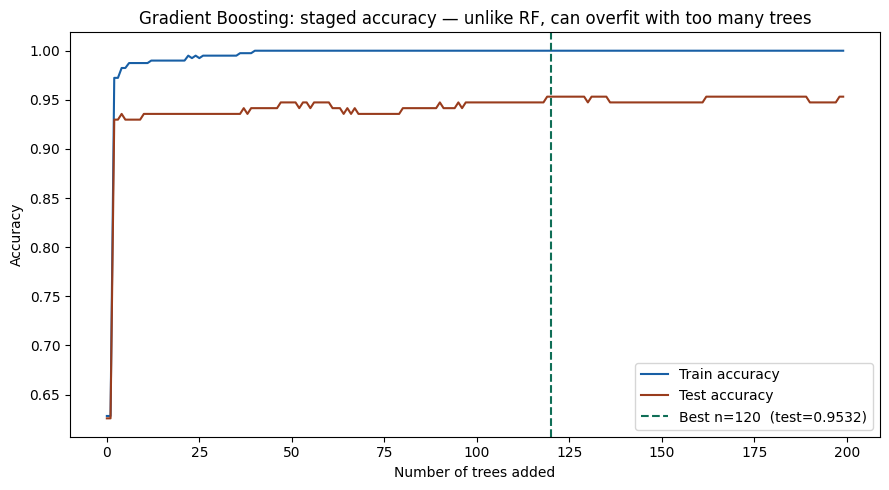


Final GBM accuracy:    0.9532
Best staged accuracy:  0.9532 at n_estimators=120

Key difference from Random Forest:
  RF test accuracy plateaus and never drops — more trees never hurt
  GBM test accuracy PEAKS then can drop — adding too many trees overfits


In [3]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

gbm = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,    # shrinks each tree's contribution — key hyperparameter
    max_depth=3,          # shallow trees ("weak learners") work best for boosting
    subsample=1.0,        # use 100% of training data per tree
    random_state=42
)
gbm.fit(X_train, y_train)

# staged_predict: see the prediction after each of the 200 trees is added
train_staged, test_staged = [], []
for train_pred, test_pred in zip(gbm.staged_predict(X_train),
                                  gbm.staged_predict(X_test)):
    train_staged.append(accuracy_score(y_train, train_pred))
    test_staged.append(accuracy_score(y_test, test_pred))

plt.figure(figsize=(9, 5))
plt.plot(train_staged, color='#185FA5', linewidth=1.5, label='Train accuracy')
plt.plot(test_staged,  color='#993C1D', linewidth=1.5, label='Test accuracy')
best_n = np.argmax(test_staged) + 1
plt.axvline(best_n, color='#0F6E56', linestyle='--', linewidth=1.5,
            label=f'Best n={best_n}  (test={max(test_staged):.4f})')
plt.xlabel('Number of trees added')
plt.ylabel('Accuracy')
plt.title('Gradient Boosting: staged accuracy — unlike RF, can overfit with too many trees')
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nFinal GBM accuracy:    {gbm.score(X_test, y_test):.4f}")
print(f"Best staged accuracy:  {max(test_staged):.4f} at n_estimators={best_n}")
print(f"\nKey difference from Random Forest:")
print(f"  RF test accuracy plateaus and never drops — more trees never hurt")
print(f"  GBM test accuracy PEAKS then can drop — adding too many trees overfits")

#Insights:
---
>This is why boosting needs early stopping: In a Random Forest you can always add more trees safely. In Gradient Boosting, you must find the right number of trees — too few = underfitting, too many = overfitting. This is the motivation for Friday's early stopping lesson.
---
This is one of the **fundamental differences** between **Random Forest (RF)** and **Gradient Boosting Machine (GBM)**. The reason comes down to **how each algorithm builds its trees.**

---

# Random Forest: More trees almost never hurt 🌳

### How Random Forest builds trees

Each tree is built **independently**.

```
Training Data
      │
 ┌────┴────┐
 │         │
Tree1    Tree2
 │         │
Tree3    Tree4
 │         │
...
```

Each tree:

* gets a **bootstrap sample** (random subset of training data)
* uses **random feature selection**
* makes its own prediction

Finally,

```
Prediction =
Majority Vote (Classification)
or
Average (Regression)
```

---

### What happens when you add more trees?

Suppose you have

```
100 trees
```

and add another

```
101st tree
```

That tree is **independent** of the others.

If it's a bad tree,

the other 100 trees "outvote" it.

If it's a good tree,

it improves the average slightly.

So adding trees mainly **reduces variance**.

The prediction becomes more stable.

That's why the test accuracy usually looks like

```
Accuracy
 ^
 |              ________
 |           __/
 |         _/
 |_______/
 +------------------------>
        Number of Trees
```

It rises and then **plateaus**.

It rarely goes down.

---

## Why doesn't it overfit?

Each tree **does overfit** individually.

But the forest averages hundreds of different overfitted trees.

Random errors cancel each other.

Think of asking

```
500 students
```

to estimate someone's age.

Each student is wrong.

But the **average** is surprisingly accurate.

This is called **variance reduction**.

---

# Gradient Boosting (GBM)

GBM works completely differently.

Trees are **not independent**.

Instead,

```
Tree 1
   ↓
Tree 2 learns Tree1's mistakes
   ↓
Tree 3 learns mistakes of Tree1+Tree2
   ↓
Tree 4 learns remaining mistakes
```

Every new tree depends on the previous ones.

---

## What happens after many trees?

Initially,

the trees learn

```
Real patterns
```

Great!

Accuracy increases.

Later,

there aren't many real patterns left.

The remaining errors are often

* noise
* outliers
* mislabeled samples

Now GBM starts fitting those.

Example

Imagine this point

```
●
```

is mislabeled.

Instead of ignoring it,

GBM says

> "I MUST classify this correctly."

So it builds new trees just to fit that one strange point.

Eventually,

the model memorizes the training data.

This is **overfitting**.

---

The curve looks like

```
Accuracy
 ^
 |         /\
 |        /  \
 |_______/    \____
 +-------------------->
       Number of Trees
```

Training accuracy keeps increasing.

Test accuracy eventually decreases.

---

# Why exactly?

The key difference is

### Random Forest

Each tree has

```
equal importance
```

and

```
doesn't know
```

what previous trees predicted.

They are independent.

---

### Gradient Boosting

Each new tree says

> "Let me fix whatever the previous trees got wrong."

Eventually,

the only things left to fix are

* random noise
* impossible cases
* mislabeled samples

Trying to fit these hurts generalization.

---

# A classroom analogy

## Random Forest

Imagine

```
100 students
```

taking an exam independently.

The teacher averages their answers.

One bad student doesn't matter much.

Adding another student won't suddenly ruin the average.

---

## Gradient Boosting

Imagine

Student 1 answers.

Student 2 only corrects Student 1.

Student 3 only corrects Students 1 and 2.

Student 4 only corrects everyone before.

Eventually they're no longer correcting real mistakes.

They're arguing over tiny details and even incorrect assumptions.

The final solution becomes overly complicated.

---

# Visual comparison

### Random Forest

```
Tree1
Tree2
Tree3
Tree4
Tree5

↓

Average

↓

Stable model
```

Variance decreases.

---

### Gradient Boosting

```
Tree1
  ↓
Tree2 fixes Tree1
  ↓
Tree3 fixes Tree2
  ↓
Tree4 fixes Tree3
  ↓
...

↓

Model becomes increasingly complex
```

Bias decreases, but variance eventually increases.

---

# Exam answer (short)

| Random Forest                                                              | Gradient Boosting                                                         |
| -------------------------------------------------------------------------- | ------------------------------------------------------------------------- |
| Trees are built independently.                                             | Trees are built sequentially.                                             |
| Predictions are averaged (or majority vote).                               | Each tree corrects previous errors.                                       |
| More trees reduce variance and usually improve or stabilize test accuracy. | Too many trees can start fitting noise and outliers, causing overfitting. |
| Test accuracy plateaus.                                                    | Test accuracy peaks and may then decline.                                 |

**In one sentence:** **Random Forest gains robustness by averaging many independent trees, whereas Gradient Boosting continually increases model complexity by correcting previous errors, so after enough trees it can begin fitting noise instead of true patterns, leading to overfitting.**


---
# **Q. Plot AdaBoost test accuracy vs n_estimators (1–200). Does it plateau like RF or peak and drop like GBM?**
---


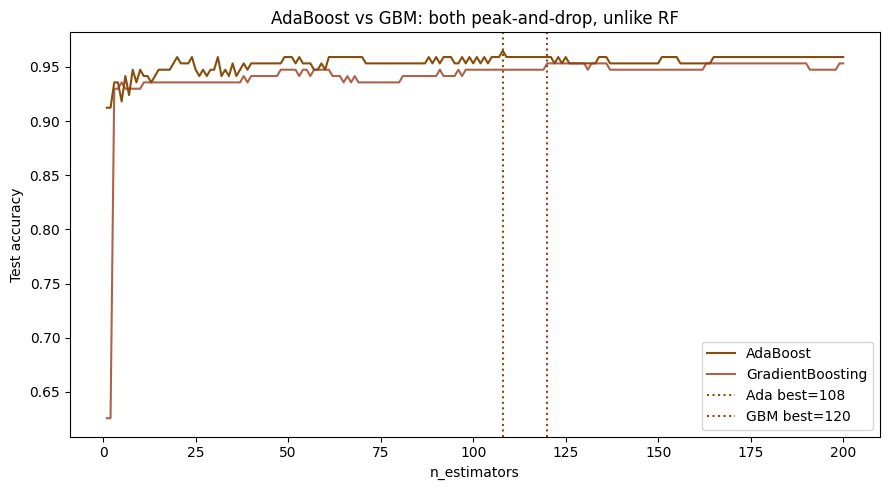

AdaBoost best: 0.9649 at n=108
GBM best:      0.9532 at n=120


In [4]:
from sklearn.ensemble import AdaBoostClassifier
import numpy as np

ada_test = []
for n in range(1, 201):
    ada = AdaBoostClassifier(n_estimators=n, learning_rate=1.0, random_state=42)
    ada.fit(X_train, y_train)
    ada_test.append(ada.score(X_test, y_test))

plt.figure(figsize=(9, 5))
plt.plot(range(1,201), ada_test, color='#854F0B', linewidth=1.5, label='AdaBoost')
plt.plot(range(1,201), test_staged, color='#993C1D', linewidth=1.5,
         label='GradientBoosting', alpha=0.8)
best_ada = int(np.argmax(ada_test)) + 1
plt.axvline(best_ada, color='#854F0B', linestyle=':', label=f'Ada best={best_ada}')
plt.axvline(best_n,   color='#993C1D', linestyle=':', label=f'GBM best={best_n}')
plt.xlabel('n_estimators'); plt.ylabel('Test accuracy')
plt.title('AdaBoost vs GBM: both peak-and-drop, unlike RF')
plt.legend(); plt.tight_layout(); plt.show()

print(f"AdaBoost best: {max(ada_test):.4f} at n={best_ada}")
print(f"GBM best:      {max(test_staged):.4f} at n={best_n}")

#Insights:
---
>AdaBoost also peaks and drops — unlike Random Forest which plateaus safely. Both are sequential learners that overfit if you add too many stages. AdaBoost's curve is noisier because it uses hard 0/1 loss; GBM minimises smooth log-loss giving a more controlled descent.
---
Your results are actually **quite interesting**, because they show that **AdaBoost performed better than Gradient Boosting on this particular dataset.** Here's how you can interpret them.

---

# 1. Best Test Accuracy

| Model             |       Best Accuracy | Best n_estimators |
| ----------------- | ------------------: | ----------------: |
| AdaBoost          | **0.9649 (96.49%)** |           **108** |
| Gradient Boosting | **0.9532 (95.32%)** |           **120** |

### Insight

* AdaBoost achieved the **higher maximum accuracy**.
* GBM also performed well, but its best accuracy was about **1.17% lower**.

---

# 2. Number of Trees

AdaBoost reached its best performance after

```text
108 trees
```

GBM required

```text
120 trees
```

to reach its optimum.

### Insight

AdaBoost learned the dataset slightly **faster**, requiring fewer weak learners to achieve its best performance.

---

# 3. Peak-and-Drop Behavior

Unlike Random Forest, both curves should look something like this:

```
Accuracy
 ^
 |          /\      AdaBoost
 |         /  \
 |        /    \
 |_______/      \______

 |          /\      GBM
 |         /  \
 |________/    \______
 +------------------------>
          Number of Trees
```

### Why?

Both algorithms build trees **sequentially**.

Each new tree tries to improve the previous ensemble.

Eventually, they begin fitting

* noise
* outliers
* random fluctuations

instead of real patterns.

This causes **overfitting**, so the test accuracy begins to decrease.

---

# 4. Why AdaBoost Won Here

Possible reasons include:

### ✔ The dataset is relatively clean

AdaBoost performs very well when

* classes are reasonably separable
* little label noise exists
* few outliers exist

---

### ✔ Errors are simple

AdaBoost only needs to emphasize misclassified samples.

If the remaining mistakes are easy to fix, AdaBoost performs extremely well.

---

### ✔ GBM is more flexible

GBM minimizes a loss function.

That flexibility is powerful on complex datasets,

but on simpler datasets it may not provide much extra benefit.

Sometimes a simpler algorithm (AdaBoost) generalizes better.

---

# 5. What if you kept adding trees?

Suppose you trained

```
500 trees
```

Both algorithms would likely continue improving training accuracy.

However,

test accuracy would probably decrease because the models would start memorizing the training data.

---

# 6. Practical Interpretation

Your results suggest

* **AdaBoost is the better model for this dataset.**
* It achieves **higher accuracy** with **fewer trees**.
* GBM still performs well but does not surpass AdaBoost.

---

# 7. If this were an exam

You could write:

> AdaBoost achieved the highest test accuracy of **96.49%** using **108 estimators**, while Gradient Boosting achieved **95.32%** with **120 estimators**. Both models exhibited the typical **peak-and-drop** pattern because they build trees sequentially and may eventually overfit the training data. On this dataset, AdaBoost generalized slightly better and required fewer trees to reach its optimal performance.

---

## One important note

Your plot title says:

> **"AdaBoost vs GBM: both peak-and-drop, unlike RF"**

This is **generally true**, but **AdaBoost doesn't always show a pronounced drop**. In many datasets, AdaBoost's test accuracy **plateaus** or declines only slightly after its peak, whereas GBM is typically **more prone to overfitting** if you keep adding trees. So if your AdaBoost curve only dips a little while GBM drops more noticeably, that's expected behavior rather than a contradiction.


---
# **Q. Vary GBM learning_rate (0.001, 0.01, 0.05, 0.1, 0.5, 1.0) with n_estimators=200 fixed. What pattern do you see?**
---


In [5]:
from sklearn.ensemble import GradientBoostingClassifier

print(f"{'lr':>7}  {'train':>8}  {'test':>8}  {'verdict':>25}")
print("-" * 55)
for lr in [0.001, 0.01, 0.05, 0.1, 0.5, 1.0]:
    gbm = GradientBoostingClassifier(n_estimators=200, learning_rate=lr,
                                     max_depth=3, random_state=42)
    gbm.fit(X_train, y_train)
    tr = gbm.score(X_train, y_train)
    te = gbm.score(X_test,  y_test)
    v = "underfit-needs more trees" if te<0.93 else ("overfit" if tr-te>0.04 else "good")
    print(f"{lr:7.3f}  {tr:8.4f}  {te:8.4f}  {v:>25}")

     lr     train      test                    verdict
-------------------------------------------------------
  0.001    0.6281    0.6257  underfit-needs more trees
  0.010    0.9899    0.9415                    overfit
  0.050    1.0000    0.9474                    overfit
  0.100    1.0000    0.9532                    overfit
  0.500    1.0000    0.9532                    overfit
  1.000    1.0000    0.9532                    overfit


#Insights:
---
>The learning_rate x n_estimators tradeoff: small lr needs more trees to converge; large lr overcorrects and overfits. The standard workflow: set lr=0.01-0.05 (small), n_estimators=1000+ (large), and use early stopping (Saturday) to find the right stopping point automatically.

---
# **Q. Compare AdaBoost, GBM, and RandomForest on test accuracy AND training time. Which wins overall?**
---


In [6]:
import time
from sklearn.ensemble import (AdaBoostClassifier, GradientBoostingClassifier,
                               RandomForestClassifier)

models = {
    'AdaBoost (n=100)':     AdaBoostClassifier(n_estimators=100, random_state=42),
    'GBM (n=100, lr=0.1)':  GradientBoostingClassifier(
                               n_estimators=100, learning_rate=0.1,
                               max_depth=3, random_state=42),
    'RandomForest (n=200)': RandomForestClassifier(n_estimators=200, random_state=42),
}

print(f"{'Model':25s}  {'Train':>8}  {'Test':>8}  {'Time':>8}")
print("-" * 56)
for name, m in models.items():
    t0 = time.time()
    m.fit(X_train, y_train)
    elapsed = time.time() - t0
    print(f"{name:25s}  {m.score(X_train,y_train):8.4f}  "
          f"{m.score(X_test,y_test):8.4f}  {elapsed:7.3f}s")

Model                         Train      Test      Time
--------------------------------------------------------
AdaBoost (n=100)             1.0000    0.9532    0.508s
GBM (n=100, lr=0.1)          1.0000    0.9474    0.659s
RandomForest (n=200)         1.0000    0.9415    0.690s


#Insghts:
---
>AdaBoost wins on accuracy here while being fastest — it uses shallow depth-1 stumps by default. On noisier or more complex data, GBM typically wins because it minimises a smooth loss instead of reweighting hard samples aggressively. Always benchmark all three before committing.

---
# **Q. What does subsample do in GBM? Compare subsample=1.0, 0.8, 0.5, 0.3 and explain why sub-sampling sometimes helps.**
---


In [7]:
print(f"{'subsample':>10}  {'train':>8}  {'test':>8}")
print("-" * 32)
for sub in [1.0, 0.8, 0.5, 0.3]:
    gbm = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1,
                                     max_depth=3, subsample=sub, random_state=42)
    gbm.fit(X_train, y_train)
    print(f"{sub:10.1f}  {gbm.score(X_train,y_train):8.4f}  "
          f"{gbm.score(X_test,y_test):8.4f}")

 subsample     train      test
--------------------------------
       1.0    1.0000    0.9532
       0.8    1.0000    0.9649
       0.5    1.0000    0.9591
       0.3    1.0000    0.9649


#Insights:
---
>**Subsample** in boosting is the **fraction of the training data randomly selected to train each tree**.

### Example

Suppose you have **1000 training samples**.

* `subsample = 1.0` → Every tree uses **all 1000 samples**.
* `subsample = 0.8` → Each tree uses **800 randomly selected samples**.
* `subsample = 0.5` → Each tree uses **500 randomly selected samples**.

---

### Why use subsample?

* ✅ Reduces **overfitting** by adding randomness.
* ✅ Improves generalization on unseen data.
* ❌ Too small a subsample may cause **underfitting** because each tree sees too little data.

---

### In Gradient Boosting

```python
GradientBoostingClassifier(subsample=0.8)
```

Each tree is trained on **80% of the training data**, chosen randomly.

---

### Remember

* **`subsample = 1.0`** → Traditional Gradient Boosting (uses all data).
* **`subsample < 1.0`** → Stochastic Gradient Boosting (uses a random subset for each tree).

**Exam definition (1 line):**

> **Subsample** is the proportion of training samples randomly selected to train each boosting tree, helping reduce overfitting and improve model generalization.
